# **Ayudantía 5: Random Forest y XGBoost**

**Curso:** Aplicaciones de Machine Learning en Economía

**Ayudantes:**
- Maykol Medrano -- mmedrano2@uc.cl
- Pablo Acevedo -- jbvillagra@uc.cl

Basado en el trabajo del equipo docente de semestres anteriores.

### **Contenidos**

1. **Random Forest** — combinación de muchos árboles entrenados en paralelo.
2. **XGBoost** — combinación de árboles entrenados secuencialmente, cada uno corrigiendo el error del anterior.
3. **Feature Importance** — qué variables aportan más a la predicción.

**Conceptos:**
- **Ensemble** — combinar varios modelos en uno.
- **Bagging vs Boosting** — paralelo vs secuencial.
- **GridSearchCV** — búsqueda de hiperparámetros con Cross Validation.

---

### **0. Recap de la Ayudantía 3**

En la Ay. 3 estimamos `MedHouseVal` (valor mediano de viviendas en distritos de California) con regresión lineal:
- 1 variable (`MedInc`): $R^2 \approx 0.47$
- 3 variables (`MedInc`, `HouseAge`, `AveRooms`): $R^2 \approx 0.50$

La regresión lineal asume que la relación entre cada variable y el precio es lineal. Hoy probamos modelos que pueden capturar relaciones no lineales.

In [2]:
# Importamos las librerías que usaremos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargamos California Housing (mismo dataset que Ay. 3)
housing = datasets.fetch_california_housing()
df = pd.DataFrame(data=housing['data'], columns=housing['feature_names'])
df['MedHouseVal'] = housing['target']

# Usamos las 8 variables disponibles (en Ay. 3 sólo usamos 3)
features = list(housing['feature_names'])
X = df[features]
y = df['MedHouseVal']

# Mismo split que Ay. 3 (test_size=0.25, random_state=15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)
print(f'Features: {features}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train: 15,480  |  Test: 5,160


In [4]:
# Regresión lineal con las 8 variables
ols = linear_model.LinearRegression()
ols.fit(X_train, y_train)

print('OLS (8 features)')
print(f'  R² Train: {r2_score(y_train, ols.predict(X_train)):.4f}')
print(f'  R² Test:  {r2_score(y_test, ols.predict(X_test)):.4f}')

OLS (8 features)
  R² Train: 0.6064
  R² Test:  0.6051


Con 3 variables el OLS dio $R^2 = 0.50$. Con las 8 variables sube a $R^2 = 0.61$. La regresión lineal no puede capturar más con estos datos por su supuesto de linealidad.

---

### **1. Random Forest**

Un árbol de decisión es inestable: un cambio pequeño en los datos puede cambiar mucho el árbol. Random Forest entrena muchos árboles distintos y promedia sus predicciones.

#### **¿Cómo se hacen distintos los árboles?**

1. **Bootstrap (muestreo con reemplazo):** cada árbol se entrena con una muestra aleatoria de los datos.
2. **Feature subsampling:** en cada nodo, el árbol solo puede elegir entre un subconjunto aleatorio de variables.

Esto se llama **Bagging** (*Bootstrap Aggregating*).

<div align="center">

<img src="https://miro.medium.com/v2/resize:fit:1400/1*5dq_1hnqkboZTcKFfwbO9A.png" style="width: 500px; height: auto;">

*Random Forest: dataset → varios árboles → mayoría / promedio. Fuente: Medium*

</div>

> En **clasificación** los árboles votan; en **regresión** sus predicciones se promedian.

#### **Hiperparámetros principales:**

| **Parámetro** | **Qué controla** |
|---|---|
| `n_estimators` | Cantidad de árboles |
| `max_depth` | Profundidad máxima de cada árbol |
| `min_samples_leaf` | Tamaño mínimo de cada hoja |
| `n_jobs=-1` | Usa todos los núcleos del CPU (los árboles son independientes) |

In [5]:
# Random Forest sobre las 8 features
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('Random Forest')
print(f'  R² Train: {r2_score(y_train, rf.predict(X_train)):.4f}')
print(f'  R² Test:  {r2_score(y_test, rf.predict(X_test)):.4f}')

Random Forest
  R² Train: 0.9072
  R² Test:  0.7992


El $R^2$ pasa de 0.61 (OLS) a 0.80 (RF) con los mismos datos. Los árboles capturan interacciones y no linealidades que la regresión lineal no puede modelar (por ejemplo, el efecto del ingreso puede variar según la latitud/longitud).

---

### **2. XGBoost**

**XGBoost** (*eXtreme Gradient Boosting*) es un modelo de boosting basado en árboles. A diferencia de Random Forest, los árboles se entrenan **secuencialmente**: cada árbol se construye para corregir los errores del anterior.

#### **Bagging vs Boosting**

| | **Bagging (Random Forest)** | **Boosting (XGBoost)** |
|---|---|---|
| **Cómo entrena los árboles** | En paralelo, independientes | Secuencial, cada uno corrige al anterior |
| **Combina las predicciones** | Promedio | Suma ponderada |
| **Reduce** | Varianza | Sesgo |

> **Conexión con Ay. 4 (overfit/underfit):** un árbol único tiene **alta varianza** (overfitting); promediar muchos árboles independientes (Bagging) la reduce. Un árbol único poco profundo tiene **alto sesgo** (underfitting); encadenar correcciones (Boosting) lo reduce. Por eso ambos métodos suelen ganarle al árbol único, pero por caminos distintos.

<div align="center">

<img src="https://miro.medium.com/v2/resize:fit:1400/1*zTgGBTQIMlASWm5QuS2UpA.jpeg" style="width: 500px; height: auto;">

*Bagging entrena modelos en paralelo; Boosting los entrena en secuencia. Fuente: Medium*

</div>

#### **Ejemplo numérico de Boosting**

Valor real a predecir: **USD 120 000**.

1. **Árbol 1** predice USD 100 000 → error = USD 20 000
2. **Árbol 2** se entrena para predecir el error de Árbol 1. Predice USD 15 000 → error restante = USD 5 000
3. **Árbol 3** intenta cubrir esos USD 5 000. Predice USD 4 000 → error = USD 1 000
4. **Predicción final:** 100 000 + 15 000 + 4 000 = **USD 119 000**

Cada árbol nuevo se enfoca en el error del modelo acumulado hasta ese punto.

In [6]:
# XGBoost con parámetros por defecto
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

print('XGBoost (default)')
print(f'  R² Train: {r2_score(y_train, xgb.predict(X_train)):.4f}')
print(f'  R² Test:  {r2_score(y_test, xgb.predict(X_test)):.4f}')

XGBoost (default)
  R² Train: 0.9488
  R² Test:  0.8342


XGBoost por defecto da $R^2 = 0.83$, sobre el 0.80 de Random Forest.

#### **Hiperparámetros principales**

| **Parámetro** | **Qué controla** | **Valores típicos** |
|---|---|---|
| `n_estimators` | Número de árboles (rondas de boosting) | 100 - 1000 |
| `max_depth` | Profundidad de cada árbol (más bajo que en RF) | 3 - 8 |
| `learning_rate` | Cuánto pesa cada árbol nuevo | 0.01 - 0.3 |
| `subsample` | Fracción de datos por árbol | 0.7 - 1.0 |

#### **Trade-off `learning_rate` vs `n_estimators`**

- `learning_rate` alto + pocos árboles → aprende rápido, riesgo de overfitting.
- `learning_rate` bajo + muchos árboles → aprende lento, suele generalizar mejor, tarda más.

> **Early stopping:** XGBoost permite detener el entrenamiento automáticamente cuando la métrica de validación deja de mejorar durante N rondas (`early_stopping_rounds=N`). Es la forma estándar de evitar agregar árboles que sólo aportan overfitting. En la práctica se usa casi siempre con boosting.

  lr=0.01: Train R²=0.7887  Test R²=0.7628
  lr=0.05: Train R²=0.8880  Test R²=0.8309
  lr=0.10: Train R²=0.9200  Test R²=0.8422
  lr=0.30: Train R²=0.9639  Test R²=0.8429
  lr=0.50: Train R²=0.9792  Test R²=0.8197


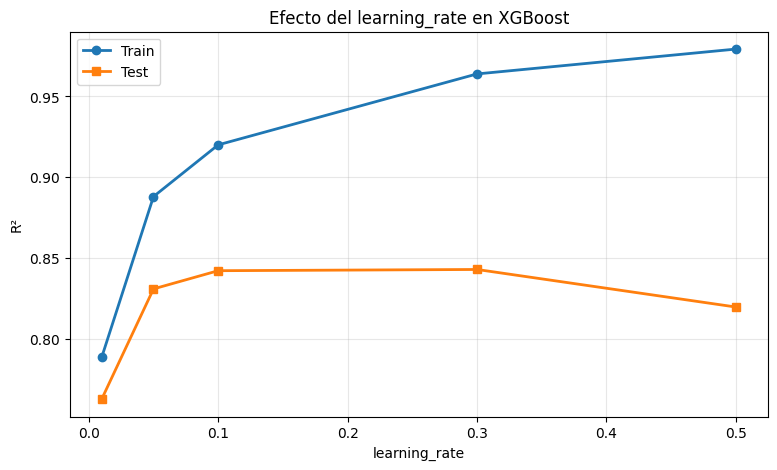

In [7]:
# Efecto del learning_rate (manteniendo n_estimators=300, max_depth=5)
lrs = [0.01, 0.05, 0.1, 0.3, 0.5]
results = []

for lr in lrs:
    xgb_lr = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=lr, random_state=42, n_jobs=-1)
    xgb_lr.fit(X_train, y_train)
    train_r2 = r2_score(y_train, xgb_lr.predict(X_train))
    test_r2 = r2_score(y_test, xgb_lr.predict(X_test))
    results.append((lr, train_r2, test_r2))
    print(f'  lr={lr:.2f}: Train R²={train_r2:.4f}  Test R²={test_r2:.4f}')

# Visualizamos
fig, ax = plt.subplots(figsize=(9, 5))
lrs_v, train_v, test_v = zip(*results)
ax.plot(lrs_v, train_v, marker='o', label='Train', linewidth=2)
ax.plot(lrs_v, test_v, marker='s', label='Test', linewidth=2)
ax.set_xlabel('learning_rate')
ax.set_ylabel('R²')
ax.set_title('Efecto del learning_rate en XGBoost')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Con `learning_rate=0.5` el Train sigue subiendo pero el Test cae — overfitting. El rango útil está entre 0.05 y 0.3.

#### **GridSearchCV**

Probamos varias combinaciones automáticamente con Cross Validation:

$$
\text{n\_estimators} \in \{200, 500\} \times \text{max\_depth} \in \{3, 5, 7\} \times \text{learning\_rate} \in \{0.05, 0.1\}
$$

Son **2 × 3 × 2 = 12 combinaciones**, cada una con 5-Fold CV → **60 entrenamientos**.

> **Otras estrategias de búsqueda de hiperparámetros**
>
> | **Método** | **Cómo busca** | **Cuándo conviene** |
> |---|---|---|
> | **Grid Search** | Prueba todas las combinaciones de la rejilla | Pocos hiperparámetros, rejilla pequeña |
> | **Random Search** (`RandomizedSearchCV`) | Muestrea aleatoriamente N combinaciones del espacio | Muchos hiperparámetros — más eficiente que grid |
> | **Bayesian Optimization** (`Optuna`, `Hyperopt`) | Aprende de las pruebas anteriores para elegir las siguientes | Espacios grandes y entrenamientos costosos |
>
> Grid Search es el más simple y el que se usa primero. Cuando el espacio crece, Random Search o Bayesian dan mejores resultados con menos entrenamientos.

In [8]:
# GridSearchCV para XGBoost
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'Mejor R² en CV: {grid.best_score_:.4f}')
print(f'R² en TEST con el mejor modelo: {r2_score(y_test, grid.predict(X_test)):.4f}')

Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
Mejor R² en CV: 0.8407
R² en TEST con el mejor modelo: 0.8485


#### **Visualizando los resultados del GridSearch**

`GridSearchCV` guarda todos los resultados en `grid.cv_results_`. Podemos armar un **heatmap** para ver qué combinaciones funcionaron mejor y detectar patrones (por ejemplo, si `max_depth` grande siempre ayuda, o si `learning_rate` importa más que `n_estimators`):

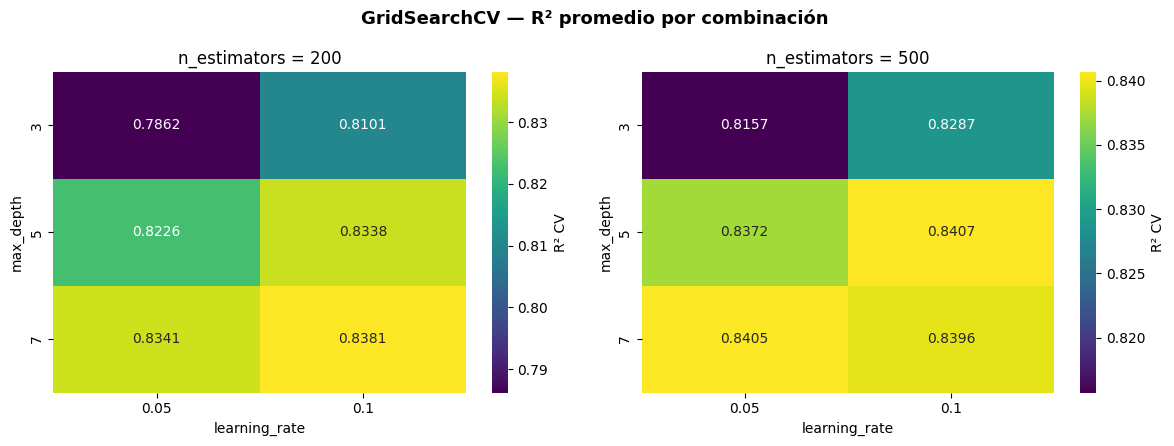

In [9]:
# Convertimos los resultados del GridSearch a DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# Heatmap: un panel por cada valor de n_estimators
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, n_est in zip(axes, [200, 500]):
    subset = cv_results[cv_results['param_n_estimators'] == n_est]
    pivot = subset.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_learning_rate'
    )
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis',
                ax=ax, cbar_kws={'label': 'R² CV'})
    ax.set_title(f'n_estimators = {n_est}')
    ax.set_xlabel('learning_rate')
    ax.set_ylabel('max_depth')

plt.suptitle('GridSearchCV — R² promedio por combinación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura del heatmap:**
- **`max_depth=3` rinde peor** (fila superior más oscura) — muy restrictivo, subajusta.
- **`n_estimators=500` domina a 200** en la mayoría de celdas — más árboles ayudan con este `learning_rate`.
- La combinación ganadora (`n_est=500, depth=5, lr=0.1`) y sus vecinas dan resultados muy similares (~0.840-0.841) → el modelo es **robusto**, no hay un único punto óptimo.

> Este tipo de visualización es muy útil para decidir si vale la pena refinar la rejilla en alguna zona, o si ya llegamos a un plateau donde agregar más tuning no cambia mucho.

---

### **3. Feature Importance**

XGBoost calcula la importancia relativa de cada variable a partir de cuánto contribuye cada una a reducir el error en el conjunto de árboles.

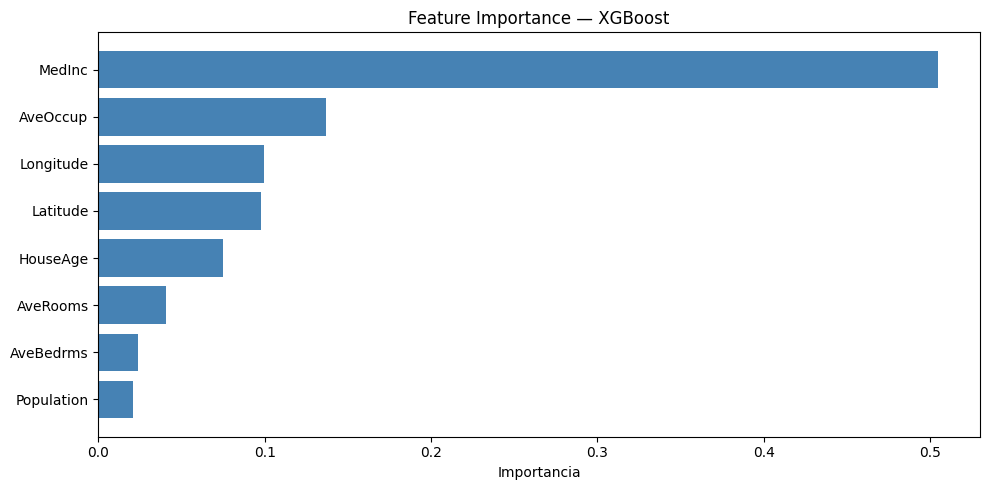

,feature,importance
0,MedInc,0.504720
5,AveOccup,0.136989
7,Longitude,0.099577
6,Latitude,0.097855
1,HouseAge,0.075141
2,AveRooms,0.040611
3,AveBedrms,0.024060
4,Population,0.021046


In [10]:
# Importancia de cada variable
best_xgb = grid.best_estimator_
imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

imp

**Lectura:**
- `MedInc` aporta ~50% — el ingreso del distrito es el principal predictor del precio.
- `AveOccup`, `Latitude`, `Longitude` suman otro ~33% — la geografía pesa.
- `HouseAge` aporta ~7%.
- `AveBedrms` y `Population` aportan poco.

---

### **4. Comparación final**

> **Métricas para regresión.** Hoy usamos $R^2$ porque es interpretable (0 = inútil, 1 = perfecto). Pero hay otras:
>
> - **RMSE** ($\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$) — castiga más fuerte los errores grandes. Útil cuando equivocarse mucho es más costoso que equivocarse poco varias veces.
> - **MAE** ($\frac{1}{n}\sum |y_i - \hat{y}_i|$) — más robusto a outliers, lineal y fácil de interpretar (misma unidad que $y$).
>
> $R^2$ sirve para comparar modelos sobre el mismo dataset; RMSE/MAE sirven cuando importan los errores absolutos en unidades reales (USD, etc.).

In [11]:
modelos = [
    ('OLS (3 vars)', linear_model.LinearRegression(), df[['MedInc', 'HouseAge', 'AveRooms']]),
    ('OLS (8 vars)', linear_model.LinearRegression(), X),
    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1), X),
    ('XGBoost (default)', XGBRegressor(random_state=42, n_jobs=-1), X),
    ('XGBoost (tuned)', best_xgb, X),
]

print(f'{"Modelo":25s} {"R² Train":>10s} {"R² Test":>10s} {"Tiempo":>8s}')
print('-' * 56)
for nombre, modelo, Xs in modelos:
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y, test_size=0.25, random_state=15)
    t0 = time.time()
    modelo.fit(Xs_tr, ys_tr)
    elapsed = time.time() - t0
    tr = r2_score(ys_tr, modelo.predict(Xs_tr))
    te = r2_score(ys_te, modelo.predict(Xs_te))
    print(f'{nombre:25s} {tr:>10.4f} {te:>10.4f} {elapsed:>7.1f}s')

Modelo                      R² Train    R² Test   Tiempo
--------------------------------------------------------
OLS (3 vars)                  0.5146     0.5041     0.0s
OLS (8 vars)                  0.6064     0.6051     0.0s
Random Forest                 0.9072     0.7992    10.2s
XGBoost (default)             0.9488     0.8342     0.4s
XGBoost (tuned)               0.9433     0.8485     1.1s


### **¿Cuándo usar cada modelo?**

| **Modelo** | **Cuándo** | **Limitación** |
|---|---|---|
| **Regresión lineal** | Datos aproximadamente lineales, se requiere interpretabilidad de coeficientes | No captura no linealidades ni interacciones |
| **Random Forest** | Baseline robusto, poco tuning | Tarda con muchos árboles + datos grandes |
| **XGBoost** | Mejor accuracy/R² en datos tabulares | Más sensible a hiperparámetros |

### **Resumen**

- OLS: $R^2 = 0.50$ (3 vars) → $0.61$ (8 vars). El supuesto de linealidad limita.
- Random Forest: $R^2 = 0.80$ — capta no linealidades.
- XGBoost: $R^2 = 0.83$ por defecto, $0.85$ con tuning.
- Cross Validation se usa para comparar modelos sin tocar el test set.
- Feature Importance permite interpretar qué variables pesan en la predicción.

### **Notas finales**

> **Otras técnicas de ensemble.** Bagging y Boosting son las dos familias clásicas, pero existen otras:
> - **Voting / Averaging** — combinar predicciones de modelos distintos sin un nivel adicional de aprendizaje.
> - **Stacking** — entrenar varios modelos (RF + XGBoost + regresión, por ejemplo) y un *meta-modelo* que aprende a combinarlos.

> **Aplicaciones reales.** Estos modelos son estándar en: **scoring crediticio**, detección de **fraude**, predicción de **churn**, *pricing* dinámico, predicción de demanda, detección de anomalías. En general, son la primera elección cuando hay datos tabulares y el objetivo es predecir bien.

> **Interpretabilidad.** RF y XGBoost dan `feature_importances_`, pero eso **no es causalidad** — solo dice qué variables el modelo usa más. Para interpretaciones más finas existe **SHAP** (`pip install shap`), que descompone cada predicción individual en la contribución de cada variable. Útil cuando hay que explicar predicciones a stakeholders o auditores.

---

##### *Para profundizar*

*Libros (cubren directamente árboles, Random Forest y Boosting):*
- *Introduction to Statistical Learning* (James, Witten, Hastie, Tibshirani) — Cap. 8. Gratuito en [statlearning.com](https://www.statlearning.com).
- *The Elements of Statistical Learning* (Hastie, Tibshirani, Friedman) — más técnico; Cap. 10 (Boosting) y 15 (Random Forests). Gratuito en [hastie.su.domains/ElemStatLearn](https://hastie.su.domains/ElemStatLearn).

*Documentación oficial:*
- scikit-learn — [Ensemble methods](https://scikit-learn.org/stable/modules/ensemble.html)
- XGBoost — [Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)

*Videos:*
- StatQuest (Josh Starmer): *Random Forests Part 1*, *XGBoost Part 1 - Regression*.
- DotCSV (Carlos Santana) — canal en español.

*Práctica:* [Kaggle Learn](https://www.kaggle.com/learn) — cursos cortos gratuitos de ML aplicado.